# Exercise:
1. Write a code to simulate 2D-ISING model with N grid points per each dimension. 
2. Compute total energy of the system.
3. Compute magnetization of the system.
4. Plot the magnetization as the function of temperature.

# Step:
1. Create initial configuration with $N^2$ sites
+ cold s= -1
+ random s= +1 or -1
+ hot s = 1
2. Compute changing energy $\Delta E = E_{final} - E_{initial}$ at lattice point $i,j$
3. Generate new configuration using Monte Carlo Metropolis method
+ if $\Delta E <= 0$, accept new spin or flip spin
+ if $\Delta E > 0$, flip spin based on Boltzmann distribution:

	- $p <= e^{-\beta \Delta E}$: accept new spin

	- $p > e^{-\beta \Delta E}$: reject new spin
4. Compute 2 quatities:

	a. total energy of the system
		$$E = -\sum_{i,j} s_i s_j$$ 
	where $i,j$ are neighbourhoods.
	
	b. Compute magnetization for each configuration after burn-in period

	$$ \langle |M| \rangle = \dfrac{1}{n}\sum_{i =1}^{n} |M_i|$$
	 with $n$ is the number of configurations and
	$$M_i = \dfrac{1}{N^2}\sum_{j=1}^{N^2} s_j$$
	c. Plot the magnetization and energy as the function of $\beta$. 

In [21]:
import numpy as np
import matplotlib.pyplot as plt

## Initial configuration

We can start in three different ways:
- **Cold**: all spins = -1 (fully ordered, low energy start)
- **Hot**: all spins = +1 (also ordered, but in the other direction)
- **Random**: spins randomly +-1 (disordered, high temperature start)

The choice of initial state can affect how quickly the system reaches equilibrium

In [22]:
def initial_config(N, start='random'):
    if start == 'cold':
        return np.full((N, N), -1)       # all spins down
    elif start == 'hot':
        return np.ones((N, N), dtype=int)  # all spins up
    else:
        # random: each spin independently +1 or -1
        return np.random.choice([-1, 1], size=(N, N))

## Total energy

The energy is computed by summing $-s_i s_j$ over all neighboring pairs. `np.roll` shifts the whole grid by one step, which gives us the neighboring columns or rows.

In [23]:
def total_energy(grid):
    # sum over all right-neighbor and down-neighbor pairs
    E = -np.sum(grid * np.roll(grid, 1, axis=0))  # interaction in row direction
    E -= np.sum(grid * np.roll(grid, 1, axis=1))  # interaction in column direction
    return E

## Energy change for a single spin flip

When we flip one spin at position $(i, j)$, we don't need to recompute the full energy — only the local contribution changes. The energy difference is:
$$\Delta E = 2 s_{i,j} \sum_{\text{neighbors}} s_{\text{neighbor}}$$

In [24]:
def delta_energy(grid, i, j):
    N = grid.shape[0]
    neighbors_sum = (
        grid[(i+1) % N, j] +
        grid[(i-1) % N, j] +
        grid[i, (j+1) % N] +
        grid[i, (j-1) % N]
    )
    return 2 * grid[i, j] * neighbors_sum

## Metropolis Monte Carlo sweep

One "sweep" = $N^2$ attempted spin flips (on average each spin is tried once). For each randomly chosen spin:
- Compute $\Delta E$
- If $\Delta E \leq 0$: accept (flip the spin)
- If $\Delta E > 0$: accept with probability $e^{-\beta \Delta E}$, otherwise reject

This is exactly the Metropolis-Hastings algorithm from the lecture.

In [25]:
def metropolis_sweep(grid, beta):
    N = grid.shape[0]
    for _ in range(N * N):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)
        dE = delta_energy(grid, i, j)
        if dE <= 0:
            grid[i, j] *= -1  # always accept if energy goes down
        elif np.random.rand() < np.exp(-beta * dE):
            grid[i, j] *= -1  # accept with Boltzmann probability
    return grid

## Magnetization

For a single configuration, the magnetization is the average spin:
$$M_i = \frac{1}{N^2} \sum_j s_j$$

I take the absolute value because the model has a symmetry: a configuration with all spins flipped has the same energy. So the average $\langle M \rangle$ would be zero even below the critical temperature, while $\langle |M| \rangle$ correctly captures the ordered phase.

In [26]:
def magnetization(grid):
    return np.abs(np.mean(grid))

## Running the simulation

In one simulation I first let the system relax, which is the burn-in part.  
After that I save measurements every few sweeps and average them.

In [27]:
N = 20              # grid size
n_burn = 500        # sweeps to discard (burn-in)
n_measure = 1000    # sweeps to measure after burn-in

beta_values = np.linspace(0.1, 0.9, 30)

mag_random = []
mag_cold   = []
mag_hot    = []
energy_random = []

for beta in beta_values:
    # --- random start ---
    grid = initial_config(N, start='random')
    for _ in range(n_burn):
        grid = metropolis_sweep(grid, beta)
    
    M_list, E_list = [], []
    for _ in range(n_measure):
        grid = metropolis_sweep(grid, beta)
        M_list.append(magnetization(grid))
        E_list.append(total_energy(grid) / N**2)
    
    mag_random.append(np.mean(M_list))
    energy_random.append(np.mean(E_list))
    
    # --- cold start ---
    grid_c = initial_config(N, start='cold')
    for _ in range(n_burn):
        grid_c = metropolis_sweep(grid_c, beta)
    mag_cold.append(np.mean([magnetization(metropolis_sweep(grid_c, beta)) for _ in range(n_measure)]))
    
    # --- hot start ---
    grid_h = initial_config(N, start='hot')
    for _ in range(n_burn):
        grid_h = metropolis_sweep(grid_h, beta)
    mag_hot.append(np.mean([magnetization(metropolis_sweep(grid_h, beta)) for _ in range(n_measure)]))

print("Simulation done!")

Simulation done!


## Visualizing the lattice

Let's quickly look at what the lattice looks like at three different temperatures: low (ordered), near-critical, and high (disordered).

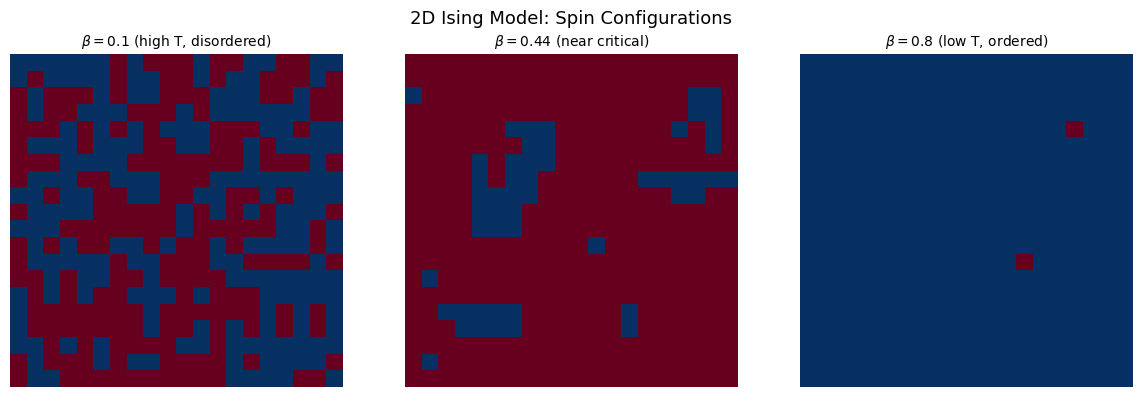

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
betas_to_show = [0.1, 0.44, 0.8]
titles = [r'$\beta = 0.1$ (high T, disordered)', r'$\beta = 0.44$ (near critical)', r'$\beta = 0.8$ (low T, ordered)']

for ax, b, title in zip(axes, betas_to_show, titles):
    g = initial_config(N, 'random')
    for _ in range(1000):
        g = metropolis_sweep(g, b)
    ax.imshow(g, cmap='RdBu', vmin=-1, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.suptitle('2D Ising Model: Spin Configurations', fontsize=13)
plt.tight_layout()
plt.savefig('ising_lattices.png', dpi=120)
plt.show()

## Magnetization and Energy vs $\beta$

Plot the main results. The key things to notice:
- **Magnetization**: jumps from ~0 to ~1 around $\beta_c \approx 0.44$ — this is the phase transition from paramagnetic to ferromagnetic.
- **Energy per spin**: becomes more negative as $\beta$ increases, meaning the spins align more at lower temperatures.
- All three starting conditions (random, cold, hot) give the same result after burn-in, which confirms the simulation is sampling from the correct Boltzmann distribution.

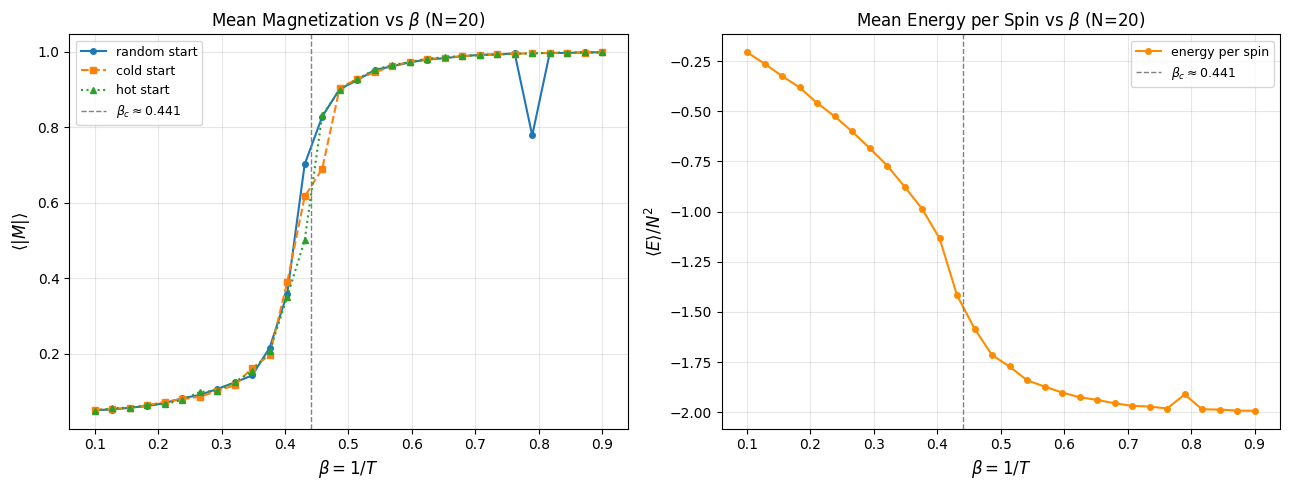

In [29]:
beta_c = np.log(1 + np.sqrt(2)) / 2  # Onsager's exact critical beta

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- magnetization ---
ax = axes[0]
ax.plot(beta_values, mag_random, 'o-', label='random start', markersize=4)
ax.plot(beta_values, mag_cold,   's--', label='cold start',   markersize=4)
ax.plot(beta_values, mag_hot,    '^:', label='hot start',    markersize=4)
ax.axvline(beta_c, color='gray', linestyle='--', linewidth=1, label=rf'$\beta_c \approx {beta_c:.3f}$')
ax.set_xlabel(r'$\beta = 1/T$', fontsize=12)
ax.set_ylabel(r'$\langle |M| \rangle$', fontsize=12)
ax.set_title(f'Mean Magnetization vs $\\beta$ (N={N})', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- energy ---
ax2 = axes[1]
ax2.plot(beta_values, energy_random, 'o-', color='darkorange', markersize=4, label='energy per spin')
ax2.axvline(beta_c, color='gray', linestyle='--', linewidth=1, label=rf'$\beta_c \approx {beta_c:.3f}$')
ax2.set_xlabel(r'$\beta = 1/T$', fontsize=12)
ax2.set_ylabel(r'$\langle E \rangle / N^2$', fontsize=12)
ax2.set_title(f'Mean Energy per Spin vs $\\beta$ (N={N})', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ising_results.png', dpi=120)
plt.show()

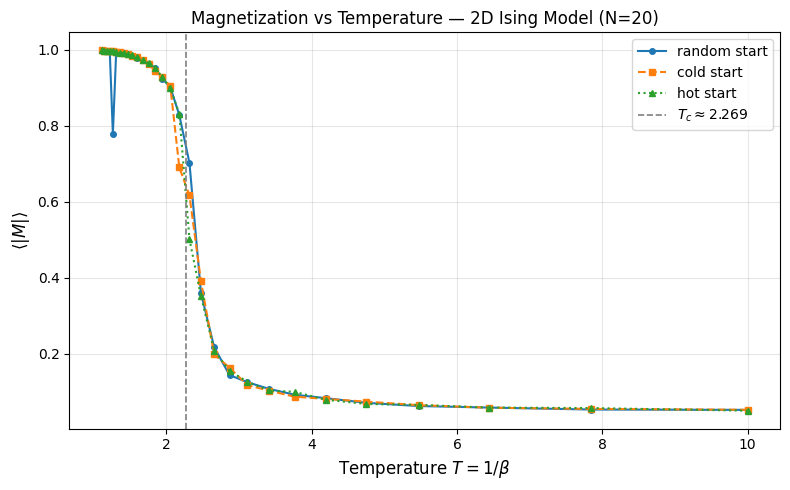

In [30]:
n = min(len(mag_random), len(mag_cold), len(mag_hot))

T_values = 1.0 / beta_values[:n]
T_c = 2.0 / np.log(1 + np.sqrt(2))

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(T_values, mag_random[:n], 'o-',  label='random start', markersize=4)
ax.plot(T_values, mag_cold[:n],   's--', label='cold start',   markersize=4)
ax.plot(T_values, mag_hot[:n],    '^:',  label='hot start',    markersize=4)

ax.axvline(T_c, color='gray', linestyle='--', linewidth=1.2,
           label=rf'$T_c \approx {T_c:.3f}$')

ax.set_xlabel(r'Temperature $T = 1/\beta$', fontsize=12)
ax.set_ylabel(r'$\langle |M| \rangle$', fontsize=12)
ax.set_title(f'Magnetization vs Temperature — 2D Ising Model (N={N})', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Observations and conclusions

The simulation clearly shows the phase transition of the 2D Ising model:

- **Above $\beta_c$** (i.e., low temperature): spins align, magnetization approaches 1, energy per spin approaches -2 (all neighbors aligned).
- **Below $\beta_c$** (i.e., high temperature): spins are disordered, magnetization ≈ 0, energy ≈ 0.
- **At $\beta_c \approx 0.44$**: there is a sharp transition. For larger grids this would become even sharper.

All three starting conditions (random, cold, hot) converge to the same values after the burn-in period. This is expected — the Metropolis algorithm generates samples from the Boltzmann distribution regardless of the starting point, as long as we give it enough time to equilibrate.